# Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms as T

import timm

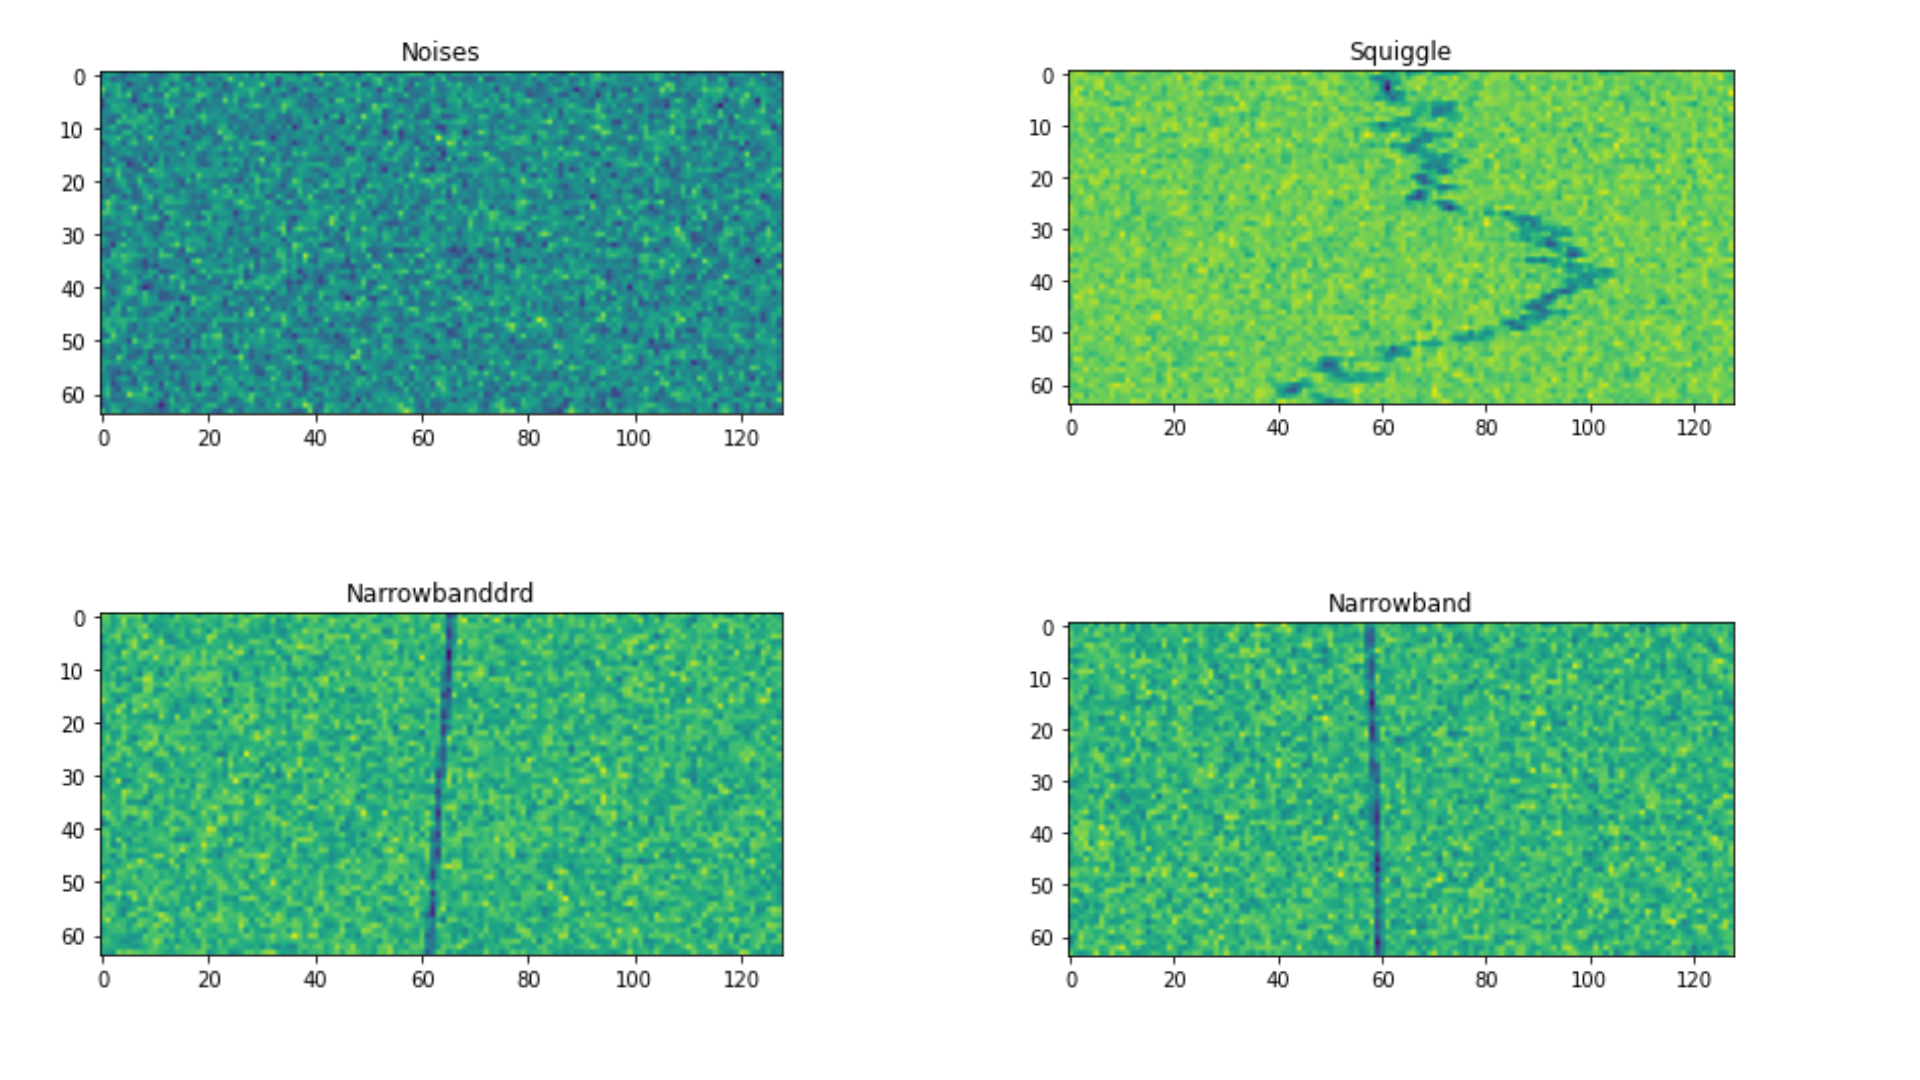

# Configurations

In [3]:
TRAIN_CSV = '/content/train.csv'
VALID_CSV = '/content/valid.csv'

BATCH_SIZE = 128
DEVICE = 'cpu'

MODEL_NAME = 'efficientnet_b0'

LR = 0.001
EPOCHS = 15

In [4]:
df_train = pd.read_csv(TRAIN_CSV)
df_valid = pd.read_csv(VALID_CSV)

In [5]:
df_train

,0,1,2,3,4,5,6,7,8,9,...,8183,8184,8185,8186,8187,8188,8189,8190,8191,labels
0,0.631373,0.623529,0.713726,0.705882,0.658824,0.666667,0.654902,0.635294,0.647059,0.705882,...,0.611765,0.650980,0.658824,0.600000,0.603922,0.654902,0.694118,0.658824,0.666667,Squiggle
1,0.725490,0.752941,0.749020,0.701961,0.690196,0.721569,0.709804,0.745098,0.654902,0.721569,...,0.698039,0.721569,0.686275,0.713726,0.682353,0.690196,0.698039,0.701961,0.725490,Squiggle
2,0.717647,0.701961,0.713726,0.733333,0.705882,0.717647,0.725490,0.682353,0.717647,0.674510,...,0.694118,0.705882,0.682353,0.639216,0.713726,0.670588,0.678431,0.737255,0.674510,Squiggle
3,0.705882,0.674510,0.654902,0.678431,0.666667,0.662745,0.678431,0.662745,0.686275,0.686275,...,0.662745,0.631373,0.643137,0.705882,0.662745,0.705882,0.666667,0.654902,0.631373,Squiggle
4,0.647059,0.729412,0.701961,0.674510,0.611765,0.698039,0.713726,0.662745,0.701961,0.674510,...,0.670588,0.705882,0.674510,0.721569,0.694118,0.674510,0.705882,0.749020,0.729412,Squiggle
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3195,0.631373,0.666667,0.627451,0.607843,0.639216,0.615686,0.623529,0.588235,0.611765,0.635294,...,0.611765,0.596078,0.607843,0.639216,0.658824,0.643137,0.627451,0.607843,0.647059,Narrowband
3196,0.662745,0.627451,0.686275,0.615686,0.639216,0.717647,0.674510,0.643137,0.729412,0.701961,...,0.627451,0.662745,0.654902,0.701961,0.701961,0.647059,0.615686,0.635294,0.623529,Narrowband
3197,0.647059,0.650980,0.643137,0.596078,0.529412,0.568627,0.607843,0.631373,0.635294,0.658824,...,0.658824,0.639216,0.647059,0.619608,0.603922,0.603922,0.643137,0.619608,0.564706,Narrowband
3198,0.694118,0.709804,0.580392,0.650980,0.631373,0.686275,0.623529,0.650980,0.678431,0.666667,...,0.674510,0.615686,0.686275,0.670588,0.619608,0.678431,0.682353,0.623529,0.647059,Narrowband


In [6]:
print(f"No. of examples present in df_train : {len(df_train)}")
print(f"No. of examples present in df_valid : {len(df_valid)}")
print(f"Labels are : {df_train['labels'].unique()}")

No. of examples present in df_train : 3200
No. of examples present in df_valid : 800
Labels are : ['Squiggle' 'Narrowbanddrd' 'Noises' 'Narrowband']


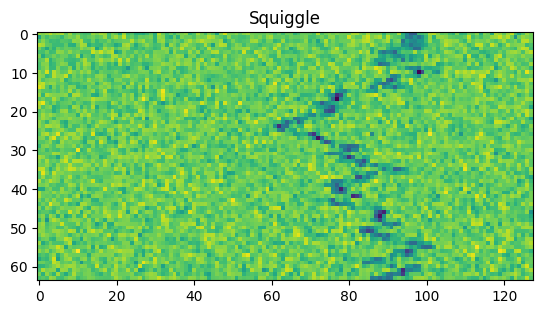

In [7]:
idx = 2

row = df_train.iloc[idx]

image_pixels = np.array(row[0:8192], dtype = np.float64)
label = row.labels

image = np.resize(image_pixels, (64, 128))

plt.imshow(image)
plt.title(label)
plt.show()

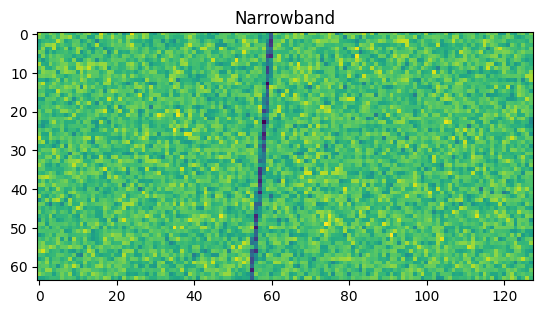

In [8]:
idx = 3100

row = df_train.iloc[idx]

image_pixels = np.array(row[0:8192], dtype = np.float64)
label = row.labels

image = np.resize(image_pixels, (64, 128))

plt.imshow(image)
plt.title(label)
plt.show()

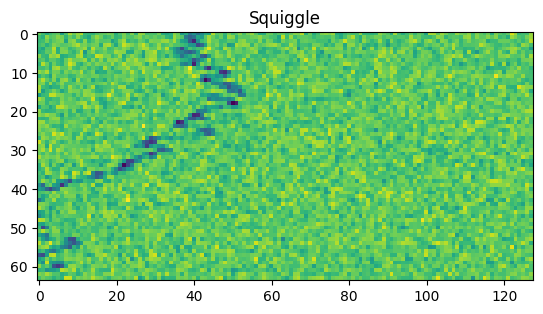

In [9]:
idx = 83

row = df_train.iloc[idx]

image_pixels = np.array(row[0:8192], dtype = np.float64)
label = row.labels

image = np.resize(image_pixels, (64, 128))

plt.imshow(image)
plt.title(label)
plt.show()

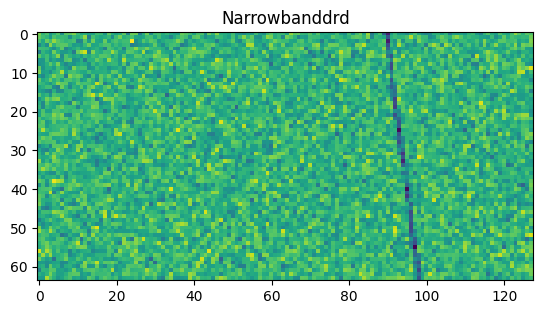

In [10]:
idx = 845

row = df_train.iloc[idx]

image_pixels = np.array(row[0:8192], dtype = np.float64)
label = row.labels

image = np.resize(image_pixels, (64, 128))

plt.imshow(image)
plt.title(label)
plt.show()

# Declare Spec Augmentations

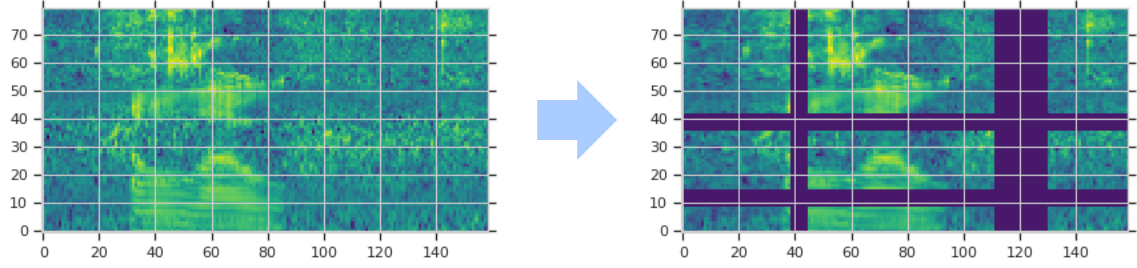

In [11]:
from torchaudio.transforms import TimeMasking, FrequencyMasking

TimeMask = TimeMasking
FreqMask = FrequencyMasking

In [12]:
def get_train_transform():
  return T.Compose([
      TimeMask(time_mask_param = 15),
      TimeMask(time_mask_param = 15),
      TimeMask(time_mask_param = 15),
      TimeMask(time_mask_param = 15),
      FreqMask(freq_mask_param = 15),
      FreqMask(freq_mask_param = 15),
      FreqMask(freq_mask_param = 15)
  ])

# Create Custom Dataset

In [13]:
class SpecDataset(Dataset):

  def __init__(self, df, augmentations = None):
    self.df = df
    self.augmentations = augmentations

    label_mapper = {
        'Squiggle' : 0,
        'Narrowband' : 1,
        'Narrowbanddrd' : 2,
        'Noises' : 3
    }

    self.df.loc[:, 'labels'] = self.df.labels.map(label_mapper)

  def __len__(self):
    return len(self.df)

  def __getitem__(self, idx):

    row = self.df.iloc[idx]
    image_pixels = np.array(row[0 : 8192], dtype = np.float64)

    image = np.resize(image_pixels, (64, 128, 1))
    label = np.array(row.labels, dtype = np.int64)

    image = torch.Tensor(image).permute(2, 0, 1)

    if self.augmentations != None:
      image = self.augmentations(image)

    return image.float(), label

In [14]:
trainset = SpecDataset(df_train, get_train_transform())
validset = SpecDataset(df_valid)

0


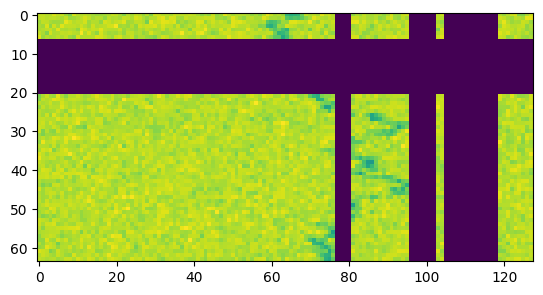

In [15]:
image, label = trainset[591]

plt.imshow(image.permute(0, 1, 2).squeeze())
print(label)

# Load dataset into Batches

In [16]:
trainloader = DataLoader(trainset, batch_size = BATCH_SIZE, shuffle = True)
validloader = DataLoader(validset, batch_size = BATCH_SIZE)

In [17]:
print(f"Total no. of batches in trainloader : {len(trainloader)}")
print(f"Total no. of batches in validloader : {len(validloader)}")

Total no. of batches in trainloader : 25
Total no. of batches in validloader : 7


In [18]:
for images, labels in trainloader:
  break;

print(f"One image batch shape : {images.shape}")
print(f"One label batch shape : {labels.shape}")

One image batch shape : torch.Size([128, 1, 64, 128])
One label batch shape : torch.Size([128])


# Load Model

In [19]:
class SpecModel(nn.Module):

  def __init__(self):
    super(SpecModel, self).__init__()

    self.net = timm.create_model(MODEL_NAME, num_classes = 4, pretrained = True, in_chans = 1)

  def forward(self, images, labels = None):

    logits = self.net(images)

    if labels != None:
      loss = nn.CrossEntropyLoss()
      return logits, loss(logits, labels)

    return logits

In [32]:
model = SpecModel()
model;

# Create Train and Eval Function

In [21]:
from tqdm.notebook import tqdm
from utils import multiclass_accuracy

In [22]:
def train_fn(model, dataloader, optimizer, current_epoch):

  model.train()
  total_loss = 0.0
  total_acc = 0.0
  progress_bar = tqdm(dataloader, desc = "EPOCH" + "[TRAIN]" + str(current_epoch + 1) + '/' + str(EPOCHS))

  for t, data in enumerate(progress_bar):
    images, labels = data
    images, labels = images.to(DEVICE), labels.to(DEVICE)

    optimizer.zero_grad()
    logits, loss = model(images, labels)
    loss.backward()
    optimizer.step()

    total_loss += loss.item()
    total_acc += multiclass_accuracy(logits, labels)

    temp = {'loss' : '%6f' %float(total_loss / (t+1)), 'acc' : '%6f' %float(total_acc / (t+1))}

    progress_bar.set_postfix(temp)

  return total_loss / len(dataloader), total_acc / len(dataloader)

In [23]:
def eval_fn(model, dataloader, current_epoch):

  model.eval()
  total_loss = 0.0
  total_acc = 0.0
  progress_bar = tqdm(dataloader, desc = "EPOCH" + "[VALID]" + str(current_epoch + 1) + '/' + str(EPOCHS))

  with torch.no_grad():
    for t, data in enumerate(progress_bar):
      images, labels = data
      images, labels = images.to(DEVICE), labels.to(DEVICE)

      logits, loss = model(images, labels)

      total_loss += loss.item()
      total_acc += multiclass_accuracy(logits, labels)

      temp = {'loss' : '%6f' %float(total_loss / (t+1)), 'acc' : '%6f' %float(total_acc / (t+1))}

      progress_bar.set_postfix(temp)

    return total_loss / len(dataloader), total_acc / len(dataloader)

# Training Loop

In [24]:
def fit(model, trainloader, validloader, optimizer):

  best_valid_loss = np.inf

  for i in range(EPOCHS):
    train_loss, train_acc = train_fn(model, trainloader, optimizer, i)
    valid_loss, valid_acc = eval_fn(model, validloader, i)

    if valid_loss < best_valid_loss:
      torch.save(model.state_dict(), MODEL_NAME + '-best-weights.pt')
      print('SAVED-BEST-WEIGHTS')
      best_valid_loss = valid_loss

In [25]:
optimizer = torch.optim.Adam(model.parameters(), lr = LR)
fit(model, trainloader, validloader, optimizer)

EPOCH[TRAIN]1/15:   0%|          | 0/25 [00:00<?, ?it/s]

EPOCH[VALID]1/15:   0%|          | 0/7 [00:00<?, ?it/s]

SAVED-BEST-WEIGHTS


EPOCH[TRAIN]2/15:   0%|          | 0/25 [00:00<?, ?it/s]

EPOCH[VALID]2/15:   0%|          | 0/7 [00:00<?, ?it/s]

...

EPOCH[VALID]13/15:   0%|          | 0/7 [00:00<?, ?it/s]

EPOCH[TRAIN]14/15:   0%|          | 0/25 [00:00<?, ?it/s]

EPOCH[VALID]14/15:   0%|          | 0/7 [00:00<?, ?it/s]

EPOCH[TRAIN]15/15:   0%|          | 0/25 [00:00<?, ?it/s]

EPOCH[VALID]15/15:   0%|          | 0/7 [00:00<?, ?it/s]

# Inference

In [26]:
from utils import view_classify

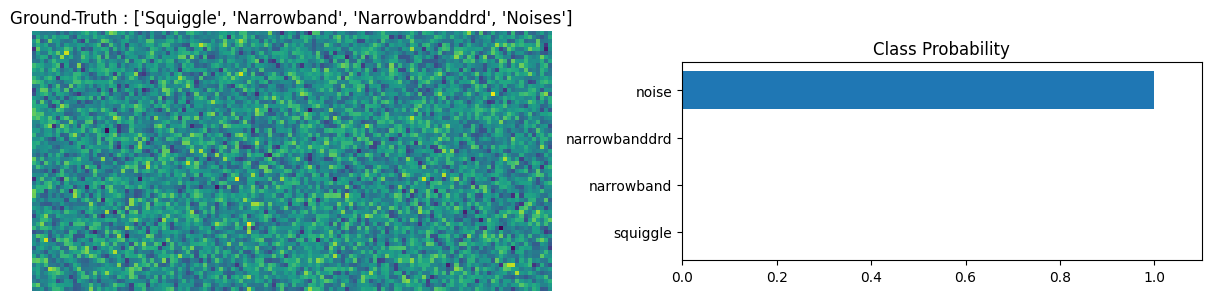

In [27]:
# 1. Load the best weights
model.load_state_dict(torch.load(MODEL_NAME + '-best-weights.pt', map_location=DEVICE))
model.to(DEVICE)
model.eval()

# 2. Get a random image from the validation set
idx = np.random.randint(len(validset))
image, label = validset[idx]

# 3. Perform Inference
with torch.no_grad():
  # Add batch dimension and move to device
  logits = model(image.unsqueeze(0).to(DEVICE))
  probs = torch.softmax(logits, dim=1)

# 4. Define classes for visualization
classes = ['Squiggle', 'Narrowband', 'Narrowbanddrd', 'Noises']

# 5. Visualize - squeezing the channel dimension for matplotlib
view_classify(image.squeeze(), probs, classes)

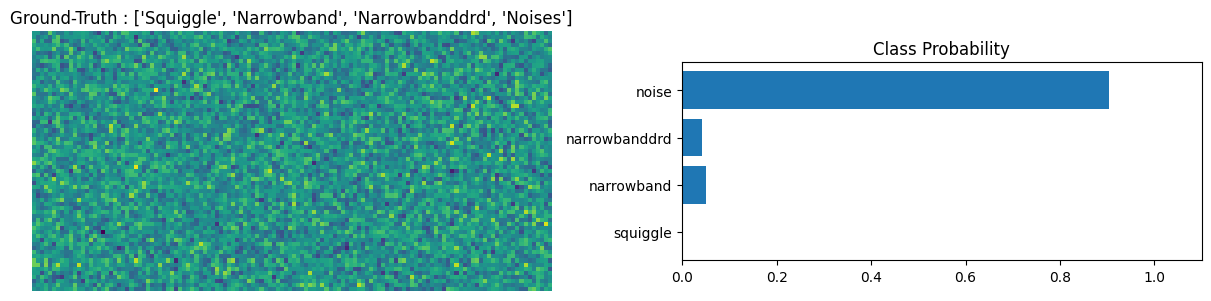

In [28]:
# Inference 2
idx = np.random.randint(len(validset))
image, label = validset[idx]
with torch.no_grad():
    logits = model(image.unsqueeze(0).to(DEVICE))
    probs = torch.softmax(logits, dim=1)
view_classify(image.squeeze(), probs, classes)

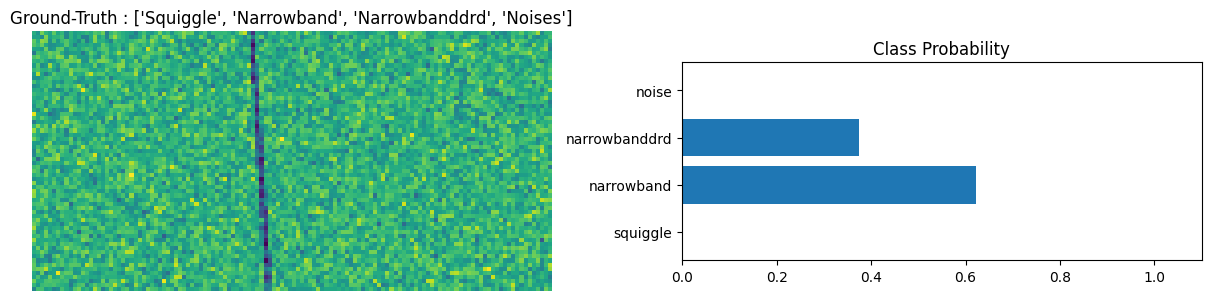

In [29]:
# Inference 3
idx = np.random.randint(len(validset))
image, label = validset[idx]
with torch.no_grad():
    logits = model(image.unsqueeze(0).to(DEVICE))
    probs = torch.softmax(logits, dim=1)
view_classify(image.squeeze(), probs, classes)

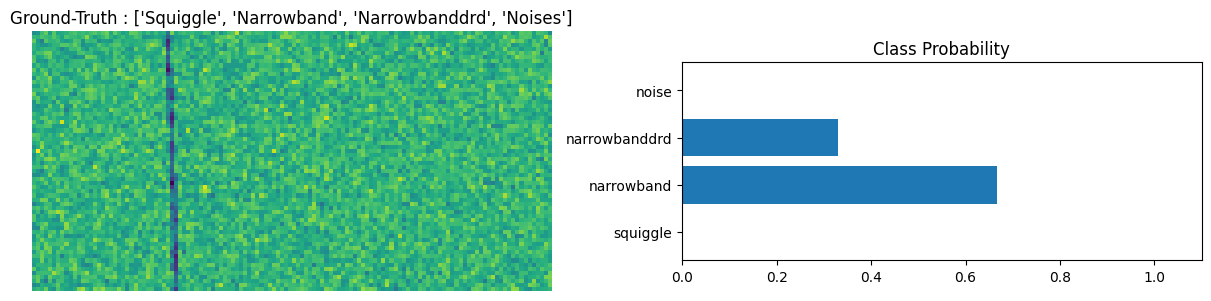

In [30]:
# Inference 4
idx = np.random.randint(len(validset))
image, label = validset[idx]
with torch.no_grad():
    logits = model(image.unsqueeze(0).to(DEVICE))
    probs = torch.softmax(logits, dim=1)
view_classify(image.squeeze(), probs, classes)

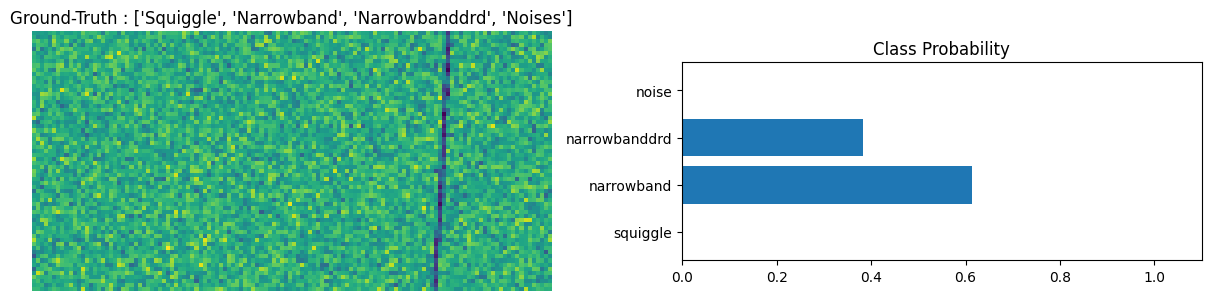

In [31]:
# Inference 5
idx = np.random.randint(len(validset))
image, label = validset[idx]
with torch.no_grad():
    logits = model(image.unsqueeze(0).to(DEVICE))
    probs = torch.softmax(logits, dim=1)
view_classify(image.squeeze(), probs, classes)